In [5]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
from os import mkdir
import os
import warnings
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data
import random

In [2]:
sc.set_figure_params(dpi=60, 
                     dpi_save=300, 
                     color_map= 'viridis_r')
plt.rcParams['figure.figsize']=(6,6) #rescale figures
plt.rcParams['grid.alpha']=0
sc.settings.verbosity = 3
sc.logging.print_header()

scanpy==1.9.5 anndata==0.10.2 umap==0.5.4 numpy==1.26.1 scipy==1.11.3 pandas==2.1.1 scikit-learn==1.3.1 statsmodels==0.14.0 pynndescent==0.5.10


In [3]:
#print shape of the matrix 
def shape(adata):
    print ('In the dataset there are:')
    print (f'{adata.obs.shape[0]} cells')
    print (f'{adata.var.shape[0]} genes')
    
## creating a boxplot to show the data distribution
def range_values_in_dataset (plot_title='Non normalized dataset'):
    tmp1=pd.DataFrame(adata.X)
    uniques=np.unique (tmp1)
    outliers_annotations = dict(markerfacecolor='g', marker='D', markersize=4, alpha=0.1,)
    box_annotations= dict(linewidth=1, color='blue', alpha=0.9 , facecolor='teal' )
    plt.boxplot (uniques, patch_artist=True, 
                 flierprops=outliers_annotations, 
                 boxprops= box_annotations )
    plt.ylabel('Unique range of values in the dataset ')
    plt.title (plot_title) ## you can notice it because the range is large
    plt.tick_params(labelbottom=False, bottom=False)
    sb.displot(uniques, kind="kde", legend=False)
    plt.tick_params(labelleft=False, left=False, )
    del uniques, tmp1

#Check how many genes form the ones we want to analyze remain after filtering
def genes_in_dataset (genes_list, dataset,):
    global found_genes
    global no_found_genes
    found_genes=[]
    no_found_genes=[]
    for gene in genes_list:
        if gene in dataset.raw.var_names:
            found_genes.append (gene)
        else:
            no_found_genes.append (gene, )
    #return found_genes, no_found_genes
    print (f'We found {len (found_genes)} out of {len(ALL_GENES)}')
    print (f'These genes are not in the datset: {no_found_genes}')

In [4]:
#Genes that we are analyzing
ALL_GENES=['oc', 'Optix', 'tll', 'Lim1', 'scro', 'Gsc', 'Rx','hh', 'wg', 'ci', 'mirr', 'ems', 'ey','erm','slp1','slp2'
         , 'Dbx', 'Ptx1', 'ths', 'pyr', 'htl', 'fd102C', 'so', 'Six4','Lim3', 'eya']
genes_homeobox=['lab', 'pb', 'Dfd', 'Scr', 'Antp', 'Ubx', 'abd-A', 'Abd-B' ] 


In [5]:
%%time
#Reading the filtered dataset
data_file='./4_droso_neuroblast_dataset/2_droso_neuroblasts_normalized_and_log_dataset.h5ad'
adata = sc.read_h5ad(data_file)

CPU times: user 69.9 ms, sys: 2.97 s, total: 3.04 s
Wall time: 3.71 s


In [6]:
adata

AnnData object with n_obs × n_vars = 32112 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [7]:
# add annotation for brain NBs
annotations = pd.read_csv("../drosophila_sc_analyses_001/cell_annotation_brain_NBs_1.csv", index_col=0)
# Align annotations to adata and fill missing with 'UNNAMED'
adata.obs['cell_types'] = (
    annotations.reindex(adata.obs_names)
    .fillna('Unknown')
)

#Removed unwanted cells in brain neuroblasts
cell_types_to_remove = [
    'Midline_NBs', 
    'PCGs', 
    'Sensory NBs', 
    'plasmatocytes/embryonic hemocytes/macrophages', 
    'Mesodermal/muscle progenitors'
]
# Filter out the cells
adata = adata[~adata.obs['cell_types'].isin(cell_types_to_remove)].copy()
adata.obs['cell_types'].value_counts()

cell_types
Unknown                           21687
NBs I                              6339
GMC                                1967
NBs II/INPs/newborn neurons_1?      596
NBs II/INPs/newborn neurons_2?      291
NBs II/INPs                          93
Name: count, dtype: int64

In [8]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 30973 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'>

In [9]:
adata


AnnData object with n_obs × n_vars = 30973 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [10]:
adata_TF = adata[:, adata.var['is_TF'] == True].copy()
adata= adata_TF
adata

AnnData object with n_obs × n_vars = 30973 × 754
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [11]:
##Recalling the raw data, that was saved originally in the layers['counts']
## This is necessary for the DE analysis
adata.X= adata.layers['counts']
adata.raw = adata

In [12]:
adata

AnnData object with n_obs × n_vars = 30973 × 754
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [13]:
#sc.pl.highest_expr_genes(adata, n_top=20, )

In [14]:
adata.obs_names_make_unique()

In [15]:
# Create an empty DataFrame to store the sums for each replicate
sums_per_replicate_df = pd.DataFrame(index=adata.var_names)

replicates_n = 10


for neuroblast in adata.obs.hox.unique():
    #check the two conditions: Hox and No_hox
    sample_subset = adata[adata.obs['hox'] == neuroblast]

    #Divide the indices (cells) of each condition in equal parts.
    #This indices are use to create pseudo replicates
    indices = list(sample_subset.obs_names)
    random.shuffle(indices)
    indices = np.array_split(np.array(indices), replicates_n)

    for i, pseudo_rep in enumerate(indices):
        #Subset the pseudoreplicates
        pseudo_rep_data = sample_subset[pseudo_rep, :].copy()
        pseudo_rep_data.obs['replicate'] = i

        # Sum the values for each gene across cells in the replicate
        sum_per_replicate = np.sum(pseudo_rep_data.X, axis=0).T

        # Store the sums in the DataFrame with gene names as indices
        sums_per_replicate_df[f'{str(neuroblast)}_{i+1}'] = sum_per_replicate

sums_per_replicate_df

,Hox_1,Hox_2,Hox_3,Hox_4,Hox_5,Hox_6,Hox_7,Hox_8,Hox_9,Hox_10,No_hox_1,No_hox_2,No_hox_3,No_hox_4,No_hox_5,No_hox_6,No_hox_7,No_hox_8,No_hox_9,No_hox_10
gene_symbol,,,,,,,,,,,,,,,,,,,,
abd-A,1123.0,1077.0,1125.0,1007.0,1073.0,1065.0,1038.0,977.0,1062.0,977.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Abd-B,1014.0,893.0,1000.0,969.0,1062.0,920.0,1014.0,980.0,906.0,947.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ac,451.0,476.0,501.0,431.0,422.0,596.0,399.0,604.0,581.0,363.0,239.0,310.0,174.0,252.0,247.0,227.0,213.0,157.0,183.0,256.0
acj6,87.0,100.0,84.0,92.0,100.0,93.0,98.0,94.0,97.0,83.0,37.0,25.0,28.0,25.0,32.0,32.0,30.0,39.0,41.0,38.0
al,25.0,22.0,16.0,19.0,12.0,13.0,4.0,11.0,18.0,21.0,1.0,1.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sima,806.0,789.0,848.0,784.0,866.0,823.0,803.0,793.0,810.0,788.0,241.0,230.0,269.0,248.0,254.0,227.0,249.0,226.0,255.0,226.0
CG45071,87.0,78.0,95.0,86.0,75.0,109.0,78.0,69.0,119.0,88.0,33.0,24.0,39.0,30.0,30.0,22.0,22.0,26.0,24.0,24.0
Sec3,107.0,96.0,116.0,98.0,108.0,95.0,97.0,105.0,123.0,105.0,39.0,50.0,31.0,53.0,22.0,28.0,37.0,34.0,36.0,38.0


In [16]:
counts= sums_per_replicate_df.T
counts

gene_symbol,abd-A,Abd-B,ac,acj6,al,aop,ap,bru1,ase,Dll,...,Traf6,Cdc5,CG44405,CG44435,CrebB,sima,CG45071,Sec3,HnRNP-K,rgr
Hox_1,1123.0,1014.0,451.0,87.0,25.0,3079.0,71.0,20.0,2154.0,59.0,...,106.0,569.0,2.0,9.0,190.0,806.0,87.0,107.0,4250.0,48.0
Hox_2,1077.0,893.0,476.0,100.0,22.0,3282.0,65.0,37.0,2293.0,32.0,...,88.0,577.0,4.0,7.0,210.0,789.0,78.0,96.0,4524.0,41.0
Hox_3,1125.0,1000.0,501.0,84.0,16.0,3260.0,71.0,28.0,2184.0,26.0,...,106.0,589.0,2.0,10.0,199.0,848.0,95.0,116.0,4449.0,46.0
Hox_4,1007.0,969.0,431.0,92.0,19.0,3148.0,64.0,25.0,2280.0,30.0,...,86.0,557.0,2.0,10.0,207.0,784.0,86.0,98.0,4431.0,45.0
Hox_5,1073.0,1062.0,422.0,100.0,12.0,3339.0,81.0,28.0,2202.0,26.0,...,93.0,570.0,2.0,11.0,206.0,866.0,75.0,108.0,4505.0,37.0
Hox_6,1065.0,920.0,596.0,93.0,13.0,3404.0,50.0,24.0,2293.0,30.0,...,84.0,529.0,0.0,14.0,194.0,823.0,109.0,95.0,4418.0,52.0
Hox_7,1038.0,1014.0,399.0,98.0,4.0,3037.0,75.0,20.0,2252.0,33.0,...,85.0,647.0,0.0,8.0,203.0,803.0,78.0,97.0,4482.0,41.0
Hox_8,977.0,980.0,604.0,94.0,11.0,3638.0,79.0,23.0,2122.0,20.0,...,89.0,536.0,2.0,7.0,221.0,793.0,69.0,105.0,4356.0,50.0
Hox_9,1062.0,906.0,581.0,97.0,18.0,3379.0,55.0,22.0,2138.0,24.0,...,86.0,583.0,1.0,7.0,209.0,810.0,119.0,123.0,4268.0,43.0
Hox_10,977.0,947.0,363.0,83.0,21.0,3423.0,44.0,19.0,2187.0,18.0,...,99.0,573.0,0.0,9.0,195.0,788.0,88.0,105.0,4417.0,44.0


In [17]:
metadata= pd.DataFrame(counts.index)
metadata.rename(columns={0: "sample"}, inplace=True)
metadata['condition'] = metadata['sample'].apply(lambda x: 'No_hox' if 'No' in x else x.split('_')[0])
metadata.set_index('sample', inplace=True)
metadata['replicate'] = metadata.index.str.extract('(\d+)', expand=False)
metadata

,condition,replicate
sample,,
Hox_1,Hox,1
Hox_2,Hox,2
Hox_3,Hox,3
Hox_4,Hox,4
Hox_5,Hox,5
Hox_6,Hox,6
Hox_7,Hox,7
Hox_8,Hox,8
Hox_9,Hox,9


In [18]:
dds= DeseqDataSet( counts=counts, metadata= metadata, design_factors= 'condition')

/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


In [19]:
dds

AnnData object with n_obs × n_vars = 20 × 754
    obs: 'condition', 'replicate'
    obsm: 'design_matrix'

In [20]:
sc.pp.filter_genes(dds, min_cells=10)

filtered out 24 genes that are detected in less than 10 cells


In [21]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.14 seconds.

Fitting dispersion trend curve...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.09 seconds.

Refitting 0 outliers.



In [22]:
dds

AnnData object with n_obs × n_vars = 20 × 730
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', 'replaceable'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks'

computing PCA
    with n_comps=19
    finished (0:00:00)


/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


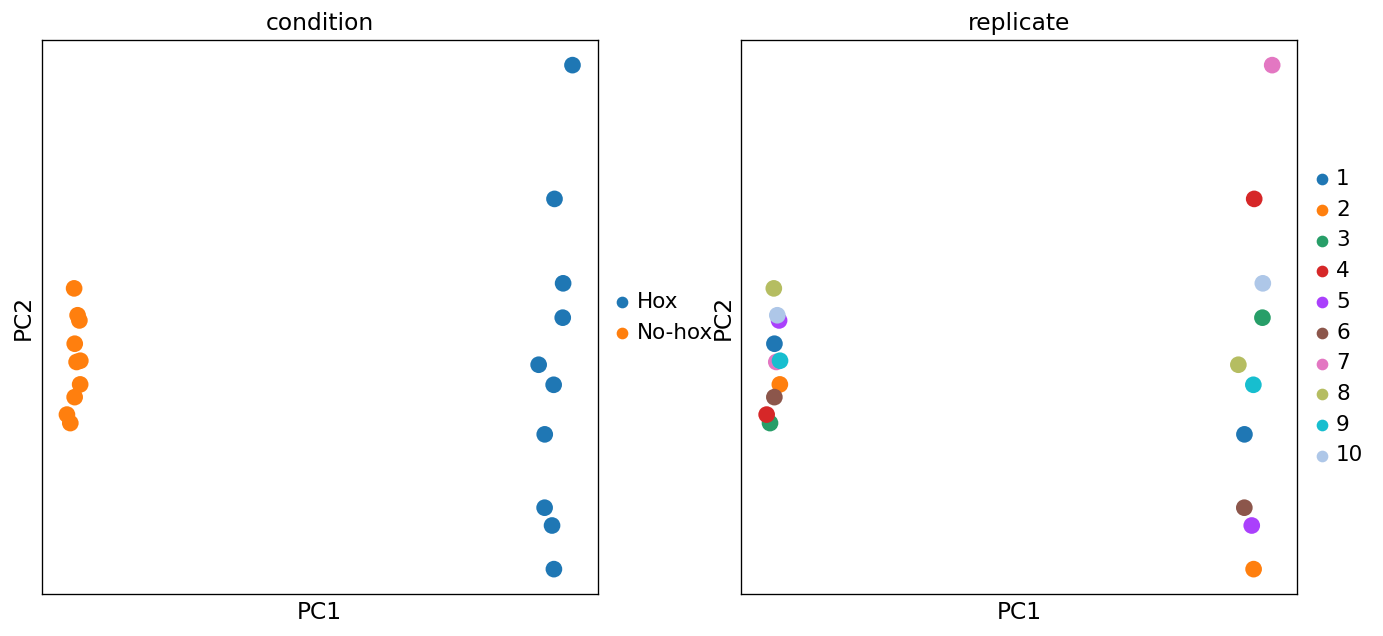

/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:324: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = ax.scatter(
/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:324: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = ax.scatter(


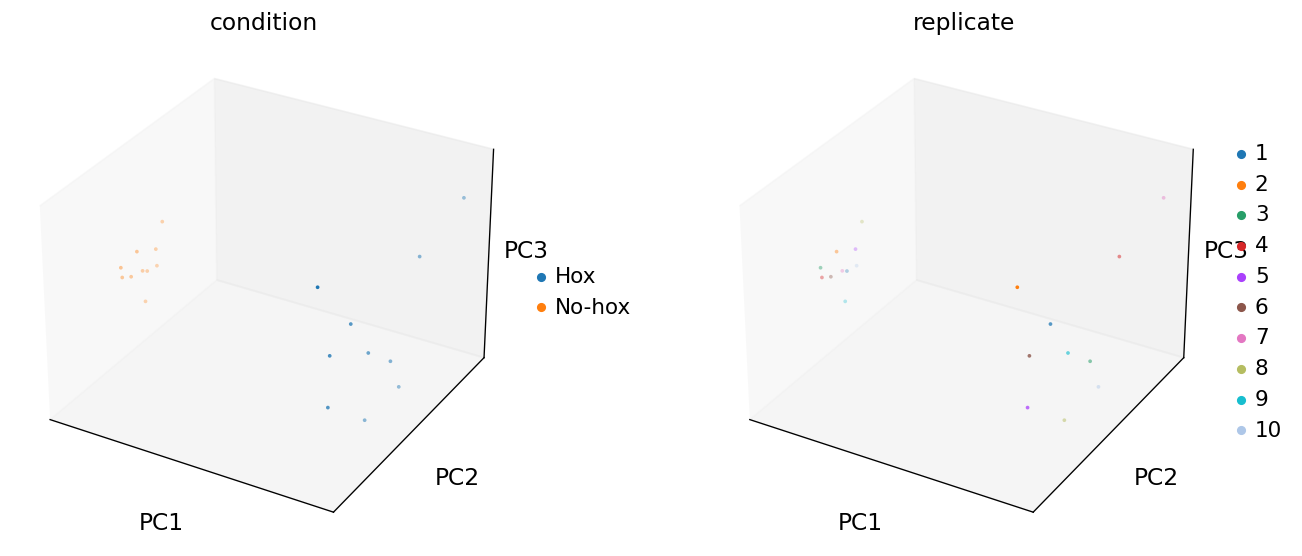

In [23]:
sc.tl.pca(dds)
sc.pl.pca(dds, color= ['condition', 'replicate'], size=400, projection='2d',)
sc.pl.pca(dds, color= ['condition', 'replicate'], size=200, projection='3d' ,)

In [24]:
stat_res= DeseqStats(dds, n_cpus=10, contrast= ('condition', 'No-hox', 'Hox') )
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition No-hox vs Hox


... done in 1.31 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_symbol,,,,,,
abd-A,302.449757,-10.892816,1.064074,-10.236899,1.355103e-24,1.513904e-23
Abd-B,278.985925,-10.776186,1.064268,-10.125441,4.260558e-24,4.686614e-23
ac,333.931108,0.491912,0.115590,4.255652,2.084408e-05,7.802890e-05
acj6,54.939316,0.084129,0.101059,0.832471,4.051434e-01,5.475946e-01
al,5.488279,-2.419911,0.523206,-4.625154,3.743193e-06,1.495186e-05
...,...,...,...,...,...,...
sima,442.874644,-0.152624,0.037112,-4.112562,3.912916e-05,1.391908e-04
CG45071,49.132584,-0.100194,0.130341,-0.768712,4.420641e-01,5.853256e-01
Sec3,62.030505,0.076732,0.106111,0.723123,4.696046e-01,6.093780e-01


In [25]:
de= stat_res.results_df
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_symbol,,,,,,
abd-A,302.449757,-10.892816,1.064074,-10.236899,1.355103e-24,1.513904e-23
Abd-B,278.985925,-10.776186,1.064268,-10.125441,4.260558e-24,4.686614e-23
ac,333.931108,0.491912,0.115590,4.255652,2.084408e-05,7.802890e-05
acj6,54.939316,0.084129,0.101059,0.832471,4.051434e-01,5.475946e-01
al,5.488279,-2.419911,0.523206,-4.625154,3.743193e-06,1.495186e-05
...,...,...,...,...,...,...
sima,442.874644,-0.152624,0.037112,-4.112562,3.912916e-05,1.391908e-04
CG45071,49.132584,-0.100194,0.130341,-0.768712,4.420641e-01,5.853256e-01
Sec3,62.030505,0.076732,0.106111,0.723123,4.696046e-01,6.093780e-01


In [26]:
de.sort_values('stat', ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_symbol,,,,,,
tll,163.468810,3.292137,0.092943,35.421051,8.097644e-275,2.894908e-272
toy,257.523123,2.943119,0.089612,32.842919,1.437602e-236,3.426284e-234
Optix,236.089952,3.300064,0.101137,32.629705,1.555133e-233,2.779801e-231
cas,1040.632752,0.756565,0.028350,26.686210,6.804698e-157,8.108932e-155
erm,64.508496,3.591088,0.143893,24.956626,1.809456e-137,1.617201e-135
...,...,...,...,...,...,...
His2Av,38576.936242,-0.126861,0.005562,-22.806821,3.923475e-115,2.805285e-113
rib,719.099976,-0.791916,0.032162,-24.622797,7.200996e-134,5.720791e-132
Mef2,148.288570,-3.352403,0.130716,-25.646387,4.639202e-145,4.738613e-143


In [27]:
#This is just to get rid of genes with low impact, it is mostl arbitrary
de=de[de.baseMean >= 10]

In [28]:
sigs= de[(de.padj < 0.05) & (abs(de.log2FoldChange) > 0.05)]
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_symbol,,,,,,
abd-A,302.449757,-10.892816,1.064074,-10.236899,1.355103e-24,1.513904e-23
Abd-B,278.985925,-10.776186,1.064268,-10.125441,4.260558e-24,4.686614e-23
ac,333.931108,0.491912,0.115590,4.255652,2.084408e-05,7.802890e-05
aop,1469.937740,-0.863377,0.063237,-13.653134,1.933808e-42,3.456682e-41
ap,42.575432,0.336003,0.137869,2.437124,1.480459e-02,3.385445e-02
...,...,...,...,...,...,...
pre-lola-G,38.258068,-0.368773,0.130541,-2.824960,4.728656e-03,1.173954e-02
l(3)neo38,3108.494725,-0.208542,0.016611,-12.554149,3.772167e-36,5.993554e-35
Cdc5,344.941041,0.130674,0.044030,2.967839,2.999012e-03,7.829030e-03


In [29]:
dds.layers['log1p']= np.log1p(dds.layers['normed_counts'])
dds

AnnData object with n_obs × n_vars = 20 × 730
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors', 'replicate_colors'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'log1p'

In [30]:
dds_sigs= dds[:, sigs.index]
dds_sigs


View of AnnData object with n_obs × n_vars = 20 × 290
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors', 'replicate_colors'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'log1p'

In [31]:
grapher=  pd.DataFrame(dds_sigs.layers['log1p'].T,
                        index=dds_sigs.var_names, columns=dds_sigs.obs_names)
grapher

sample,Hox_1,Hox_2,Hox_3,Hox_4,Hox_5,Hox_6,Hox_7,Hox_8,Hox_9,Hox_10,No_hox_1,No_hox_2,No_hox_3,No_hox_4,No_hox_5,No_hox_6,No_hox_7,No_hox_8,No_hox_9,No_hox_10
gene_symbol,,,,,,,,,,,,,,,,,,,,
abd-A,6.476087,6.415134,6.464121,6.371659,6.419759,6.426804,6.387545,6.354365,6.413276,6.328810,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Abd-B,6.374152,6.228123,6.346533,6.333259,6.409471,6.280702,6.364192,6.357425,6.254689,6.297679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ac,5.566087,5.600681,5.657128,5.525318,5.489060,5.847586,5.434146,5.874526,5.811474,5.341740,6.034970,6.259754,5.714006,6.113796,6.052082,5.981883,5.914934,5.618995,5.740216,6.083306
aop,7.483709,7.528307,7.527044,7.510287,7.553866,7.587668,7.460012,7.667795,7.569577,7.581320,6.907996,6.745022,6.999864,7.163566,6.919753,6.901049,7.132378,6.715186,7.006926,6.922026
ap,3.737567,3.632748,3.724133,3.640685,3.855749,3.400407,3.781354,3.858902,3.482279,3.265647,3.301677,4.005389,3.668533,3.741648,4.083687,3.974569,3.937917,3.979190,3.980354,3.923119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pre-lola-G,3.854231,3.894771,3.764539,3.769021,3.546695,3.893872,3.868638,3.557505,3.835012,3.808768,3.580111,3.268140,3.083436,3.555573,3.612223,3.714568,3.667845,3.800601,3.552320,3.344355
l(3)neo38,8.101589,8.083244,8.116804,8.120955,8.118844,8.121915,8.084063,8.114726,8.125542,8.129768,8.018654,7.957646,7.970772,7.961509,7.959468,7.986046,7.925303,7.960084,8.023936,7.903923
Cdc5,5.797706,5.792459,5.818426,5.780873,5.788618,5.728700,5.915857,5.755442,5.814900,5.796466,5.901184,5.944427,5.731044,5.842554,5.936610,5.927712,5.900788,6.008313,5.823776,5.861706


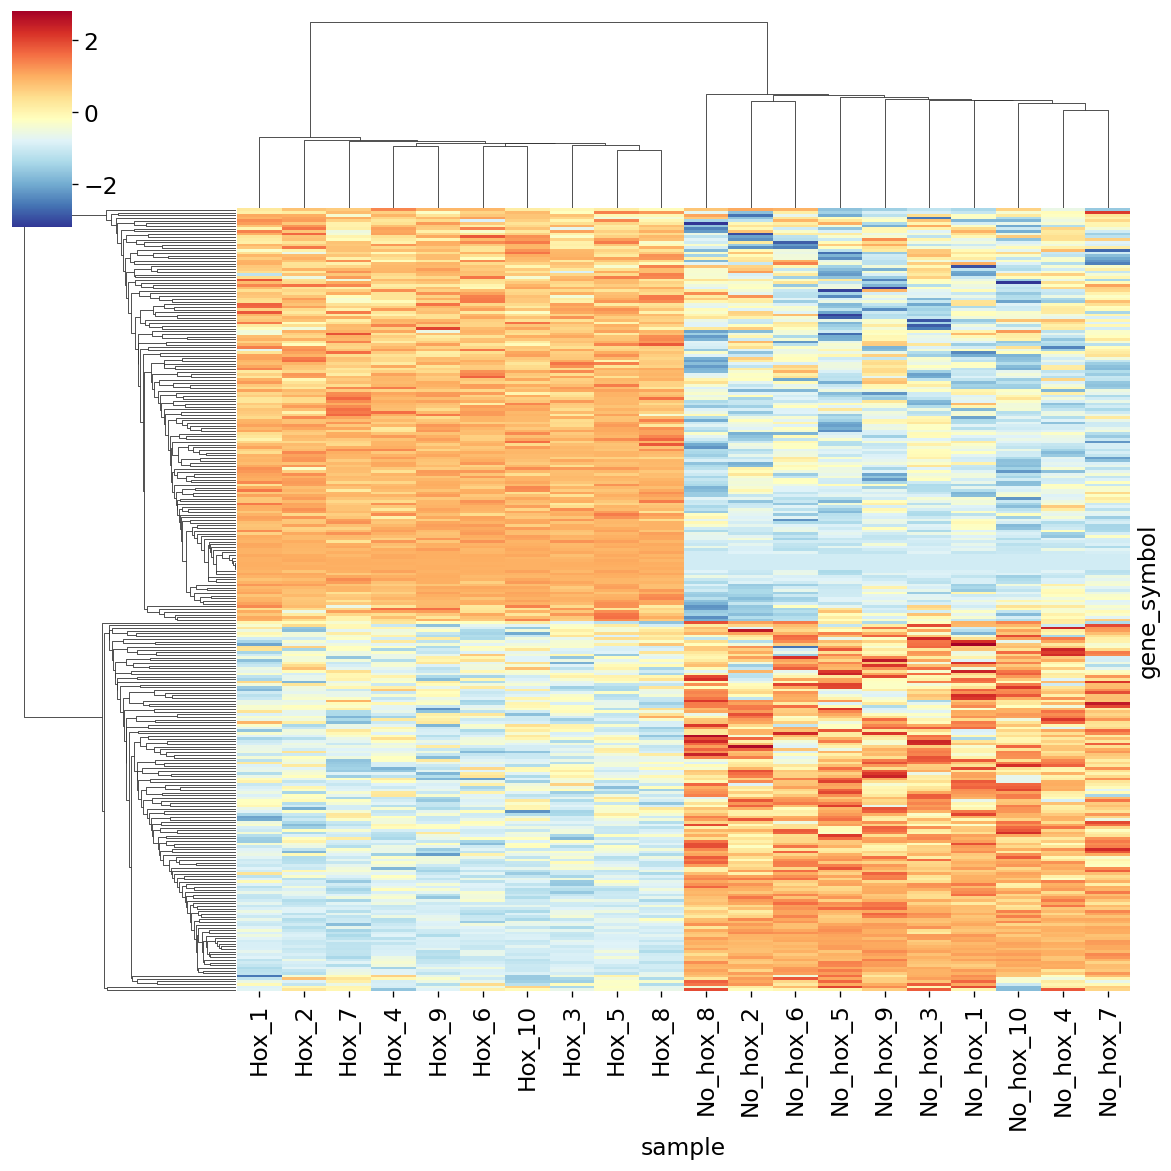

In [32]:
sb.clustermap(grapher, z_score=0,cmap= 'RdYlBu_r', yticklabels=False)

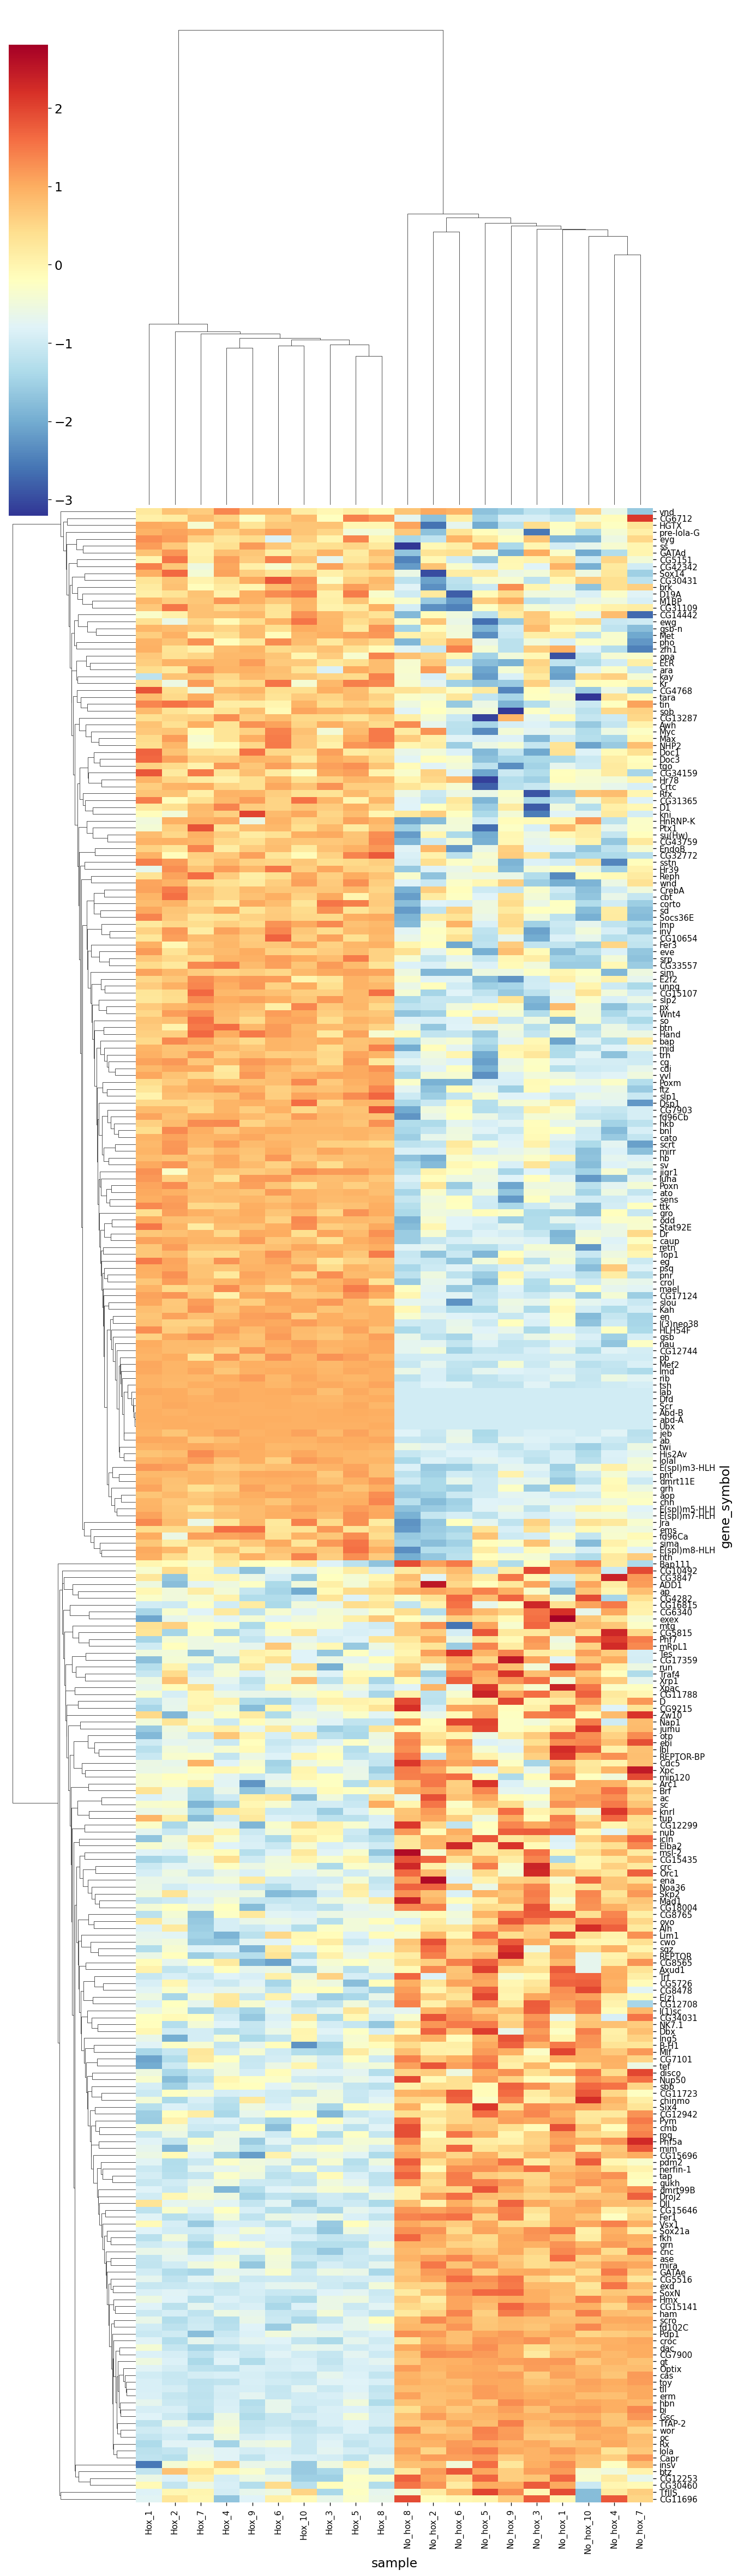

In [33]:
g = sb.clustermap(
    grapher,
    z_score=0,
    cmap='RdYlBu_r',
    figsize=(12, 40),       # adjust width/height as needed
    yticklabels=True,
    xticklabels=True,)

g.ax_heatmap.tick_params(labelsize=9)
g.fig.savefig("figures/heatmap_DE_TF_genes_drosophila_with_hox_genes.pdf", dpi=300, )

In [34]:
# Reordered row and column indices (as numpy arrays)
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

# Reorder the DataFrame according to the clustering order
ordered_data = grapher.iloc[row_order, col_order]

# Show the first few rows
print(ordered_data.head())

# Save to CSV if you want
ordered_data.to_csv('4_droso_neuroblast_dataset/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')

sample          Hox_1     Hox_2     Hox_7     Hox_4     Hox_9     Hox_6  \
gene_symbol                                                               
vnd          5.130044  5.205384  5.186212  5.292143  5.223680  5.225040   
CG6712       6.494586  6.498681  6.529010  6.518029  6.478769  6.515554   
HGTX         5.520905  5.513245  5.328993  5.504300  5.421964  5.477238   
pre-lola-G   3.854231  3.894771  3.868638  3.769021  3.835012  3.893872   
eyg          3.695445  3.617657  3.263986  3.085520  3.198959  2.436369   

sample         Hox_10     Hox_3     Hox_5     Hox_8  No_hox_8  No_hox_2  \
gene_symbol                                                               
vnd          5.114989  5.088656  5.115815  5.072844  5.199379  5.245055   
CG6712       6.530735  6.480843  6.556918  6.546228  6.457838  6.409020   
HGTX         5.479803  5.481450  5.374149  5.375411  5.525949  5.027654   
pre-lola-G   3.808768  3.764539  3.546695  3.557505  3.800601  3.268140   
eyg          3.287271  2

In [35]:
#In case writing to save the file throws errir run this lines
filtered_data = dds.uns['trend_coeffs']
# Convert values to strings
dds.uns['trend_coeffs']= {key: str(value) for key, value in filtered_data.items()}

### saving PyDEseq files
animal='droso'
gene_types= 'TFs_including_Hox'
folder= '4_droso_neuroblast_dataset'

pydesed_file= f'4_{gene_types}_PyDEseq_analysis_{animal}.h5ad' #This file is going to be used for the the downstream analysis
dds.write(pydesed_file)
os.system (f'mv {pydesed_file} {folder}')

0

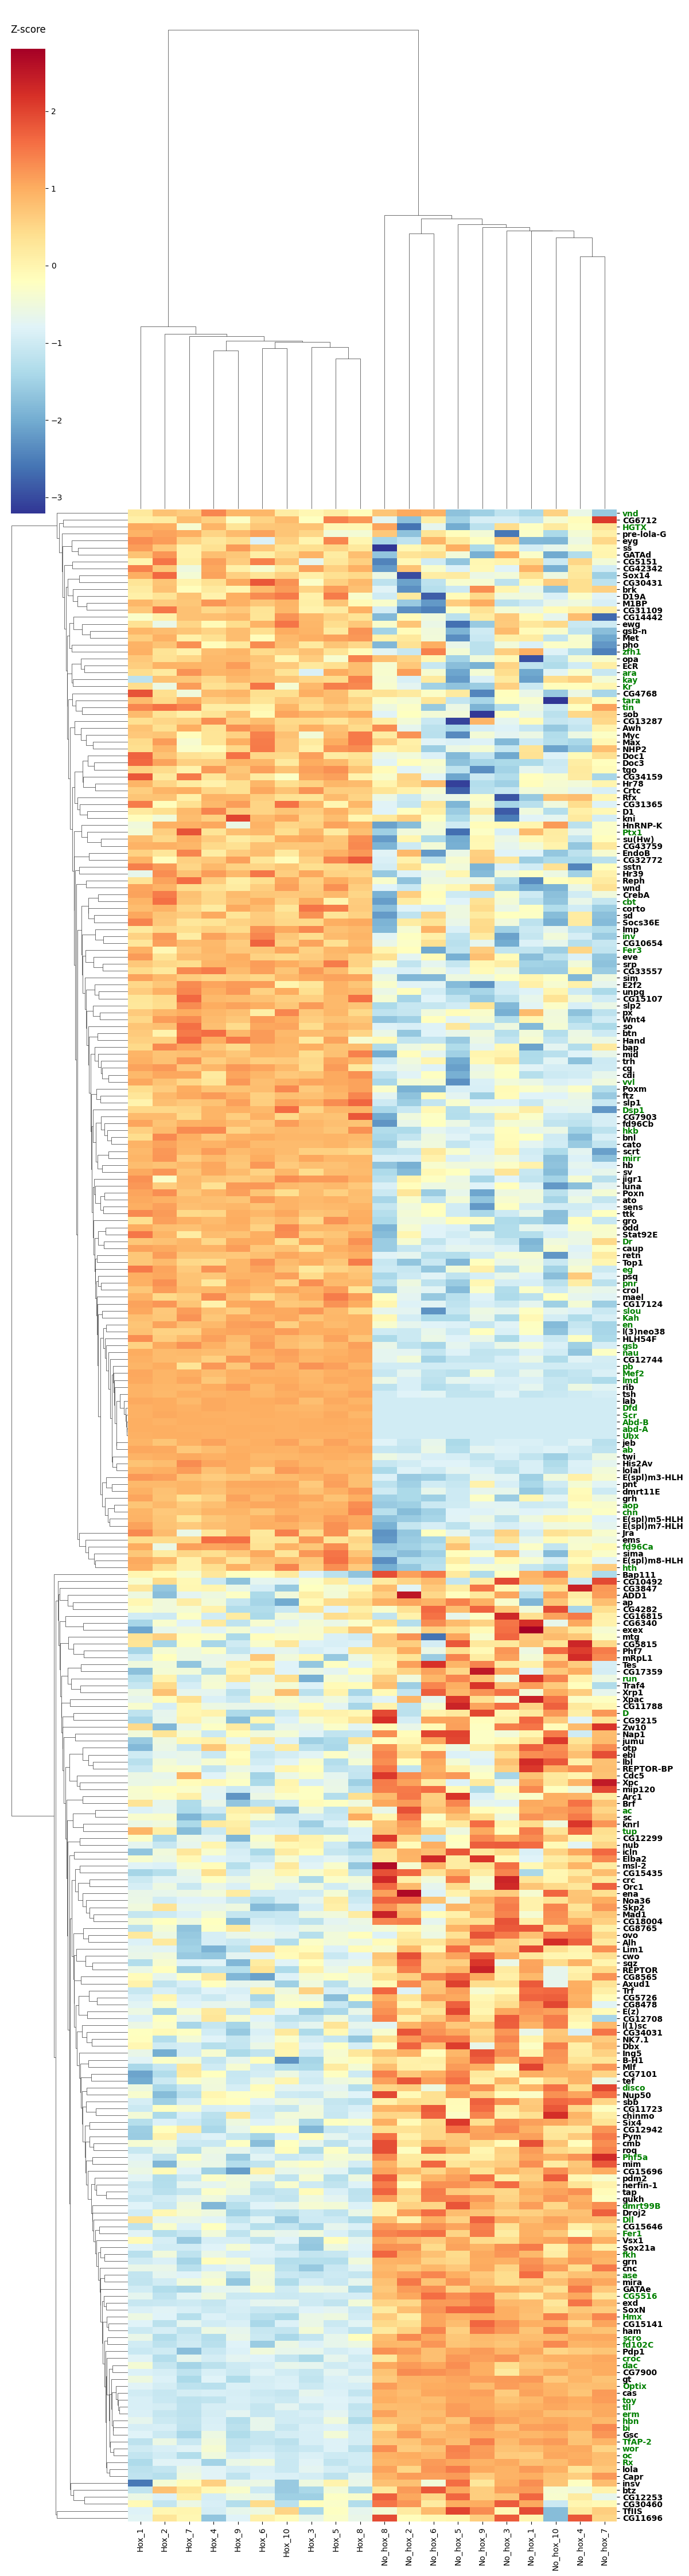

In [11]:
#Update label colors

#updated heatmap plot

# Shared TFs

vnc_shared= ['Abd-B', 'Dfd', 'Dr', 'Dsp1', 'Fer3', 'HGTX', 'Kah', 'Kr', 'Mef2', 'Ptx1', 'Scr', 'Ubx', 'ab', 'abd-A', 'aop', 'ara', 'cbt', 'chn', 'eg', 'en', 'fd96Ca', 'gsb', 'hkb', 'hth', 'inv', 'kay', 'lmd', 'mirr', 'nau', 'pb', 'pnr', 'slou', 'tara', 'tin', 'vnd', 'vvl', 'zfh1']
brain_shared= ['CG5516', 'D', 'Dll', 'Fer1', 'Hmx', 'Optix', 'Phf5a', 'Rx', 'TfAP-2', 'ac', 'ase', 'bi', 'croc', 'dac', 'disco', 'dmrt99B', 'erm', 'fd102C', 'fkh', 'hbn', 'oc', 'run', 'scro', 'tll', 'toy', 'tup', 'wor']

shared_tfs = vnc_shared + brain_shared
sss = pd.read_csv('../ven_diagrams_Droso_Tribo_001/TFS_found/Drosophila/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')
#sss.drop(columns=['gene_originals', 'Nbs_type'], inplace=True)

# Keep only numeric columns for clustermap
data_numeric = sss.select_dtypes(include=['float', 'int'])
row_labels = sss['gene_symbol']

# Create the clustermap
ss = sb.clustermap(
    data_numeric,
    z_score=0,            # normalize rows (genes)
    cmap='RdYlBu_r',
    figsize=(12, 45),
    yticklabels=row_labels,
    xticklabels=True
)

ss.ax_heatmap.tick_params(axis='y', labelsize=12)
ss.ax_heatmap.tick_params(axis='x', labelsize=12)

cbar = ss.ax_heatmap.collections[0].colorbar
cbar.ax.set_title("Z-score", fontsize=12, pad=20)

# Change tick label colors for shared TFs
for label in ss.ax_heatmap.get_yticklabels():
    label.set_fontweight(600)   # heavier than 'bold'
    if label.get_text() in shared_tfs:
        label.set_color('green')

ss.ax_heatmap.tick_params(labelsize=10)

ss.fig.savefig("figures/heatmap_DE_TF_genes_drosophila_without_hox_genes_updated.pdf", dpi=300)
plt.show()
